Using device: cuda

✅ Final Splits: Train (85%): 29109, Test (15%): 5137

🚀 Using best HPs: lr=3e-05, bs=8, epochs=8

🔍 5-Fold CV on TRAIN (85%) with best HPs...

--- Fold 1/5 ---


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at /root/.ssh/MyDeepLearning-Experiment/models/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epochs: 100%|██████████| 8/8 [51:00<00:00, 382.56s/it, train_loss=0.1589, val_loss=1.4274, val_acc=0.7193]


  → Fold 1 Val Acc: 0.7193

--- Fold 2/5 ---


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at /root/.ssh/MyDeepLearning-Experiment/models/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epochs: 100%|██████████| 8/8 [51:47<00:00, 388.40s/it, train_loss=0.1484, val_loss=1.4697, val_acc=0.7241]


  → Fold 2 Val Acc: 0.7241

--- Fold 3/5 ---


...

  → Fold 4 Val Acc: 0.7193

--- Fold 5/5 ---


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at /root/.ssh/MyDeepLearning-Experiment/models/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epochs: 100%|██████████| 8/8 [51:29<00:00, 386.17s/it, train_loss=0.1504, val_loss=1.4867, val_acc=0.7165]


  → Fold 5 Val Acc: 0.7165

📊 3-Fold CV on TRAIN (85%): 0.6015 ± 0.2646

🎯 Retraining final RoBERTa on FULL TRAIN (85%)...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at /root/.ssh/MyDeepLearning-Experiment/models/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epochs: 100%|██████████| 8/8 [1:03:13<00:00, 474.24s/it, train_loss=0.1586, val_loss=0.2166, val_acc=0.9140]



✅ Saved RoBERTa model  to: ./roberta_best

🟩 FINAL TEST ACCURACY (Held-Out, Natural Distribution): 0.7393

=== FINAL CLASSIFICATION REPORT (TEST SET) ===
                precision    recall  f1-score   support

self-direction     0.7820    0.7683    0.7751       859
   stimulation     0.7468    0.7357    0.7412       401
      hedonism     0.8463    0.8100    0.8277      1142
   achievement     0.5621    0.5772    0.5695       298
         power     0.7771    0.7871    0.7821       310
      security     0.7990    0.8267    0.8127       404
    conformity     0.6319    0.6616    0.6464       659
     tradition     0.7745    0.7953    0.7848       298
   benevolence     0.6906    0.6703    0.6803       646
  universalism     0.4306    0.5167    0.4697       120

      accuracy                         0.7393      5137
     macro avg     0.7041    0.7149    0.7089      5137
  weighted avg     0.7424    0.7393    0.7406      5137



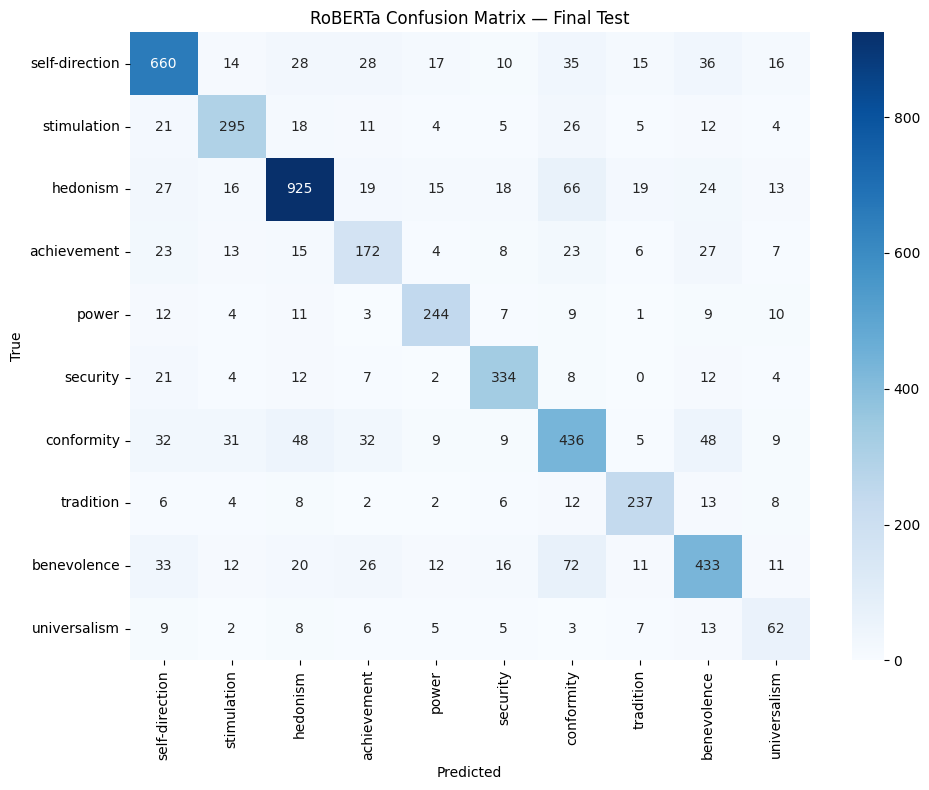

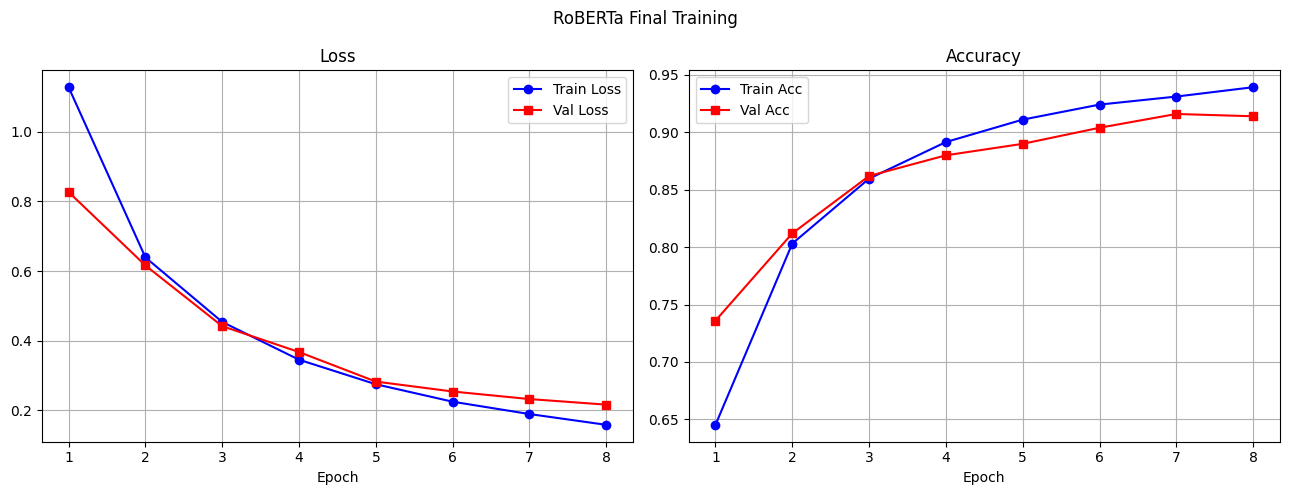

In [3]:
# RoBERTa (base) 
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm, trange
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
# Load & Map Labels 
df = pd.read_excel('combineddataset.xls')

y_dict = {
    'self-direction': 0, 'stimulation': 1, 'hedonism': 2, 'achievement': 3, 'power': 4,
    'security': 5, 'conformity': 6, 'tradition': 7, 'benevolence': 8, 'universalism': 9
}
class_labels = [k for k in y_dict.keys()]
n_classes = len(class_labels)

df['category'] = df['category'].str.strip().str.lower()
df = df[df['category'].isin(y_dict)]
df['label_id'] = df['category'].map(y_dict).astype(int)

#  REVISED SPLIT: 85% Train / 15% Test
texts = df['Base_Reviews'].values
y_int = df['label_id'].values

X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    texts, y_int, test_size=0.15, random_state=SEED, stratify=y_int
)

print(f"\n✅ Final Splits: Train (85%): {len(X_train_raw)}, Test (15%): {len(X_test_raw)}")

# Tokenizer 
tokenizer = RobertaTokenizerFast.from_pretrained('/root/.ssh/MyDeepLearning-Experiment/models/roberta-base')

def tokenize_texts(texts, max_len):
    return tokenizer(
        [str(t) for t in texts],
        padding='max_length', truncation=True, max_length=max_len,
        return_tensors='pt', return_attention_mask=True
    )



class TextDS(Dataset):
    def __init__(self, toks, labels):
        self.ids = toks['input_ids']
        self.msk = toks['attention_mask']
        self.y = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, i):
        return {
            'input_ids': self.ids[i],
            'attention_mask': self.msk[i],
            'labels': self.y[i]
        }

# Train/Eval utilities
def train_one_run(train_loader, val_loader, epochs, lr, weight_decay=0.01):
    model = RobertaForSequenceClassification.from_pretrained(
        '/root/.ssh/MyDeepLearning-Experiment/models/roberta-base', num_labels=n_classes
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )

    best_val_acc = -1.0
    best_state = None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    epoch_iterator = trange(epochs, desc="Epochs", leave=True)

    for ep in epoch_iterator:
        #  Train 
        model.train()
        tr_loss, tr_correct, tr_seen = 0.0, 0, 0
        
        train_iterator = tqdm(
            train_loader,
            desc=f"Epoch {ep+1}/{epochs} [Train]",
            leave=False,
            dynamic_ncols=True
        )

        for batch in train_iterator:
            optimizer.zero_grad()
            inputs = batch['input_ids'].to(device)
            masks = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(inputs, attention_mask=masks, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()

            tr_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            tr_correct += (preds == labels).sum().item()
            tr_seen += labels.size(0)

            # Update batch progress bar with loss & acc
            batch_acc = tr_correct / tr_seen
            train_iterator.set_postfix({
                'loss': f"{tr_loss / (tr_seen // labels.size(0) + 1e-8):.4f}",
                'acc': f"{batch_acc:.4f}"
            })

        avg_tr_loss = tr_loss / len(train_loader)
        avg_tr_acc = tr_correct / max(1, tr_seen)
        history['train_loss'].append(avg_tr_loss)
        history['train_acc'].append(avg_tr_acc)

        #  Validate 
        model.eval()
        val_loss, val_correct, val_seen = 0.0, 0, 0

        val_iterator = tqdm(
            val_loader,
            desc=f"Epoch {ep+1}/{epochs} [Eval]",
            leave=False,
            dynamic_ncols=True
        )

        with torch.no_grad():
            for batch in val_iterator:
                inputs = batch['input_ids'].to(device)
                masks = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                outputs = model(inputs, attention_mask=masks, labels=labels)
                val_loss += outputs.loss.item()
                preds = torch.argmax(outputs.logits, dim=1)
                val_correct += (preds == labels).sum().item()
                val_seen += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_correct / max(1, val_seen)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)

        #  Update epoch bar with key metrics
        epoch_iterator.set_postfix({
            'train_loss': f"{avg_tr_loss:.4f}",
            'val_loss': f"{avg_val_loss:.4f}",
            'val_acc': f"{avg_val_acc:.4f}"
        })

        # Save best model
        if avg_val_acc > best_val_acc + 1e-6:
            best_val_acc = avg_val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    return model, best_val_acc, history

def evaluate_on_loader(model, data_loader):
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0.0
    with torch.no_grad():
        for batch in data_loader:
            inputs = batch['input_ids'].to(device)
            masks = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(inputs, attention_mask=masks, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = (y_true == y_pred).mean()
    avg_loss = total_loss / len(data_loader)
    return acc, avg_loss, y_true, y_pred

#  BEST HPs: lr=3e-5, batch_size=8, epochs=8
BEST_LR = 3e-5
BEST_BS = 8
BEST_EPOCHS = 8
MAXLEN = 128

print(f"\n🚀 Using best HPs: lr={BEST_LR}, bs={BEST_BS}, epochs={BEST_EPOCHS}")

# =========================
# 5-FOLD CV ON TRAIN (85%) WITH BEST HPs
# =========================
print(f"\n🔍 5-Fold CV on TRAIN (85%) with best HPs...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_raw, y_train_raw), 1):
    print(f"\n--- Fold {fold}/5 ---")
    
    X_tr_raw = X_train_raw[tr_idx]
    X_v_raw = X_train_raw[val_idx]
    y_tr_raw = y_train_raw[tr_idx]
    y_v_raw = y_train_raw[val_idx]
    
    # Oversample ONLY fold-train
    ros = RandomOverSampler(random_state=SEED)
    X_tr_res, y_tr_res = ros.fit_resample(X_tr_raw.reshape(-1, 1), y_tr_raw)
    X_tr_res = X_tr_res.flatten()
    
    # Tokenize
    tok_tr = tokenize_texts(X_tr_res, MAXLEN)
    tok_v = tokenize_texts(X_v_raw, MAXLEN)
    
    train_ds = TextDS(tok_tr, y_tr_res)
    val_ds = TextDS(tok_v, y_v_raw)
    
    train_loader = DataLoader(train_ds, batch_size=BEST_BS, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BEST_BS)
    
    model, val_acc, _ = train_one_run(
        train_loader, val_loader, 
        epochs=BEST_EPOCHS, 
        lr=BEST_LR
    )
    print(f"  → Fold {fold} Val Acc: {val_acc:.4f}")
    cv_results.append({'fold': fold, 'val_acc': val_acc})

# Summarize CV
cv_df = pd.DataFrame(cv_results)
mean_cv = cv_df['val_acc'].mean()
std_cv = cv_df['val_acc'].std()
print(f"\n📊 3-Fold CV on TRAIN (85%): {mean_cv:.4f} ± {std_cv:.4f}")

# FINAL MODEL: Retrain on FULL OVERSAMPLED TRAIN (85%)
print(f"\n🎯 Retraining final RoBERTa on FULL TRAIN (85%)...")

# Oversample FULL TRAIN only
ros_final = RandomOverSampler(random_state=SEED)
X_train_res, y_train_res = ros_final.fit_resample(X_train_raw.reshape(-1, 1), y_train_raw)
X_train_res = X_train_res.flatten()

# Tokenize
tok_train_final = tokenize_texts(X_train_res, MAXLEN)
tok_test_final = tokenize_texts(X_test_raw, MAXLEN)

train_ds_final = TextDS(tok_train_final, y_train_res)
test_ds_final = TextDS(tok_test_final, y_test)

train_loader_final = DataLoader(train_ds_final, batch_size=BEST_BS, shuffle=True)
test_loader_final = DataLoader(test_ds_final, batch_size=BEST_BS)

# Train final model
final_model, _, final_history = train_one_run(
    train_loader_final, 
    DataLoader(TextDS(tokenize_texts(X_train_raw[:500], MAXLEN), y_train_raw[:500]), 
               batch_size=BEST_BS),
    epochs=BEST_EPOCHS, 
    lr=BEST_LR
)

# Save
SAVE_DIR = './roberta_best'
os.makedirs(SAVE_DIR, exist_ok=True)
final_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"\n✅ Saved RoBERTa model  to: {SAVE_DIR}")

# FINAL EVALUATION ON TEST SET (15%)
test_acc, test_loss, y_true_test, y_pred_test = evaluate_on_loader(final_model, test_loader_final)
print(f"\n🟩 FINAL TEST ACCURACY (Held-Out, Natural Distribution): {test_acc:.4f}")

print("\n=== FINAL CLASSIFICATION REPORT (TEST SET) ===")
print(classification_report(y_true_test, y_pred_test, target_names=class_labels, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('RoBERTa Confusion Matrix — Final Test')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig('RoBERTa_ConfusionMatrix_Test.png', dpi=300, bbox_inches='tight')
plt.show()

# Learning Curves
plt.figure(figsize=(13, 5))
epochs = range(1, len(final_history['train_loss']) + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs, final_history['train_loss'], 'b-o', label='Train Loss')
plt.plot(epochs, final_history['val_loss'], 'r-s', label='Val Loss')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, final_history['train_acc'], 'b-o', label='Train Acc')
plt.plot(epochs, final_history['val_acc'], 'r-s', label='Val Acc')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend(); plt.grid(True)

plt.suptitle('RoBERTa Final Training')
plt.tight_layout()
plt.savefig('RoBERTa_LearningCurves.png', dpi=300, bbox_inches='tight')
plt.show()